In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [2]:
def get_var_size():
    # Get all variables in the current namespace
    variables = {name: value for name, value in globals().items() if not name.startswith("__")}

    # Sort variables by size
    sorted_vars = sorted(variables.items(), key=lambda x: sys.getsizeof(x[1]), reverse=True)

    # Print variable sizes
    for name, value in sorted_vars:
        print(f"{name}: {sys.getsizeof(value) / 1024:.2f} KB")

In [97]:
# from scipy.signal._arraytools import _validate_fs

def iircomb(w0, Q, ftype='notch', fs=2.0, *, pass_zero=False):
    
    # Convert w0, Q, and fs to float
    w0 = float(w0)
    Q = float(Q)
    fs = float(fs)

    # Check for invalid cutoff frequency or filter type
    ftype = ftype.lower()
    if not 0 < w0 < fs / 2:
        raise ValueError(f"w0 must be between 0 and {fs / 2}"
                         f" (Nyquist), but given {w0}.")
    if ftype not in ('notch', 'peak'):
        raise ValueError('ftype must be either notch or peak.')

    # Compute the order of the filter
    N = round(fs / w0)

    # Check for cutoff frequency divisibility
    if abs(w0 - fs/N)/fs > 1e-14:
        raise ValueError('fs must be divisible by w0.')

    # Compute frequency in radians and filter bandwidth
    # Eq. 11.3.1 (p. 574) from reference [1]
    w0 = (2 * np.pi * w0) / fs
    w_delta = w0 / Q

    # Define base gain values depending on notch or peak filter
    # Compute -3dB attenuation
    # Eqs. 11.4.1 and 11.4.2 (p. 582) from reference [1]
    if ftype == 'notch':
        G0, G = 1, 0
    elif ftype == 'peak':
        G0, G = 0, 1

    # Compute beta according to Eq. 11.5.3 (p. 591) from reference [1]. Due to
    # assuming a -3 dB attenuation value, i.e, assuming GB = 1 / np.sqrt(2),
    # the following term simplifies to:
    #   np.sqrt((GB**2 - G0**2) / (G**2 - GB**2)) = 1
    beta = np.tan(N * w_delta / 4)

    # Compute filter coefficients
    # Eq 11.5.1 (p. 590) variables a, b, c from reference [1]
    ax = (1 - beta) / (1 + beta)
    bx = (G0 + G * beta) / (1 + beta)
    cx = (G0 - G * beta) / (1 + beta)

    # Last coefficients are negative to get peaking comb that passes zero or
    # notching comb that doesn't.
    negative_coef = ((ftype == 'peak' and pass_zero) or
                     (ftype == 'notch' and not pass_zero))

    # Compute numerator coefficients
    # Eq 11.5.1 (p. 590) or Eq 11.5.4 (p. 591) from reference [1]
    # b - cz^-N or b + cz^-N
    b = np.zeros(N + 1)
    b[0] = bx
    if negative_coef:
        b[-1] = -cx
    else:
        b[-1] = +cx

    # Compute denominator coefficients
    # Eq 11.5.1 (p. 590) or Eq 11.5.4 (p. 591) from reference [1]
    # 1 - az^-N or 1 + az^-N
    a = np.zeros(N + 1)
    a[0] = 1
    if negative_coef:
        a[-1] = -ax
    else:
        a[-1] = +ax

    return b, a

In [3]:
# fly_num = '208'
# fly_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}'
# filter_name = 'functional_channel_2_moco_warp_blurred_hpf_dff_filtered_total.h5'
# STA_path = os.path.join(fly_path, 'temp_filter', filter_name)
# later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'

# n_clusters=2000


In [4]:
# # fly_list=['208', '209', '210', '217', '218', '226', '227', '228', '233', '234', '239', '240', '241', '242', '249', '250']
# fly_list=['208', '209', '210', '217', '218', '226', '227', '228', '233', '234']
# cluster_dir = os.path.join(later_dir, 'clustering')
# if not os.path.exists(cluster_dir):
#     os.mkdir(cluster_dir)
# save_file = os.path.join(cluster_dir, f'cluster_labels_{fly_list[0]}_{fly_list[-1]}.npy')
# cluster_labels_total=np.load(save_file)
# print(np.shape(cluster_labels_total))

In [5]:
# label_num = '208'
# label_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}'
# single_fly_cluster_dir=os.path.join(label_path, 'func_0','clustering')
# save_file_fly = os.path.join(single_fly_cluster_dir, f'cluster_labels_2_total_3000.npy')
# cluster_labels_single=np.load(save_file_fly)
# print(np.shape(cluster_labels_single))

In [6]:
# for file in os.listdir(later_dir):
#     if '_total' in file and fly_num in file:
#         tf_file = file
#         print(tf_file)

In [7]:
# %%time
# brain_path=os.path.join(later_dir, tf_file)
# with h5py.File(brain_path, 'r+') as hf:
#     brain = hf['brain'][:]
#     brain[np.isnan(brain)] = 0
#     dims=np.shape(brain)
#     print(f'brain shape: {dims}')

In [8]:
# ########################################
# ########################################
# cluster_labels = cluster_labels_single
# ########################################
# ########################################

In [9]:
# all_signals = []
# for z in range(dims[-2]):
#     neural_activity = brain[:,:,z,:].reshape(-1, dims[3])
#     signals = []
#     for cluster_num in range(n_clusters):
#         cluster_indicies = np.where(cluster_labels[z,:]==cluster_num)[0]
#         mean_signal = np.mean(neural_activity[cluster_indicies,:], axis=0)
#         signals.append(mean_signal)
#     signals = np.asarray(signals)
#     all_signals.append(signals)
# all_signals = np.asarray(all_signals)
# print(np.shape(all_signals))

In [10]:
# signal_move=np.moveaxis(all_signals, 1,-1)
# print(np.shape(signal_move))

In [11]:
def supervoxel_to_full_res(brain, cluster_labels):
    n_clusters = brain.shape[2]
    n_tp = brain.shape[1]
    brain_dims=[314,146]
    
    reformed_brain = []
    for z in range(brain.shape[0]):
        colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]))
        for cluster_num in range(n_clusters):
            cluster_mask = cluster_labels[z,:]==cluster_num
#             print(cluster_indicies)
            colored_by_betas[:,cluster_mask] = brain[z,:,cluster_num,np.newaxis]
        colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1])
        reformed_brain.append(colored_by_betas)
    return np.asarray(reformed_brain)


In [12]:
# %%time
# reformed_brain = supervoxel_to_full_res(signal_move, cluster_labels)

In [13]:
# %%time
# super_vox_brain = gaussian_filter1d(reformed_brain,sigma=1,axis=1,truncate=1)

In [14]:
# brain_temp=np.moveaxis(super_vox_brain,0,-1)
# brain_final=np.moveaxis(brain_temp,0,-1).astype('float32')
# dims=np.shape(brain_final)
# print(dims)

In [15]:
# z=45

In [16]:
# print(dims)
# plt.figure(figsize=(10,10))
# plt.imshow(np.mean(brain_final[...,z,:], axis=-1).T)

In [17]:
# print(dims)
# plt.figure(figsize=(10,10))
# plt.imshow(brain_final[...,z,500].T)

In [18]:
### big STA supervox
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'


behaviors = ['total', 'inc', 'dec', 'flat']

n_clusters=2000

step_size=20


In [19]:
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))

In [20]:
behave_dict = {}

for behavior in behaviors:
    behave_dir = os.path.join(later_dir, behavior)
#     print(behave_dir)
    behave_dict[behavior]=[]
    for file in os.listdir(behave_dir):
        if 'STA' in file and str(step_size) in file:
            STA_path=os.path.join(behave_dir, file)
            with h5py.File(STA_path, 'r') as sf:
                brain = sf['data'][:]
                brain[np.isnan(brain)] = 0
                brain[np.isinf(brain)] = 4
                brain = np.moveaxis(brain, 0, -1)
                dims=np.shape(brain)
                print(f'brain shape: {dims}')
                behave_dict[behavior]=brain
                

brain shape: (314, 146, 91, 120)
brain shape: (314, 146, 91, 120)
brain shape: (314, 146, 91, 120)
brain shape: (314, 146, 91, 120)


In [21]:
behave_dict.keys()

dict_keys(['total', 'inc', 'dec', 'flat'])

In [22]:
%%time
supervox_dict={}
for behave in behaviors:
    supervox_dict[behave]={}
    brain = behave_dict[behave]
    dims = np.shape(brain)
    supervox_dict[behave]['signals']=[]
    for z in range(dims[-2]):
        neural_activity = brain[:,:,z,:].reshape(-1, dims[3])
        signals = []
        for cluster_num in range(n_clusters):
            cluster_indicies = np.where(giant_cluster_labels[z,:]==cluster_num)[0]
            mean_signal = np.mean(neural_activity[cluster_indicies,:], axis=0)
            signals.append(mean_signal)
        signals = np.asarray(signals)
        supervox_dict[behave]['signals'].append(signals)
    supervox_dict[behave]['signals'] = np.asarray(supervox_dict[behave]['signals'])
    print(np.shape(supervox_dict[behave]['signals']))

(91, 2000, 120)
(91, 2000, 120)
(91, 2000, 120)
(91, 2000, 120)
CPU times: user 35.3 s, sys: 352 ms, total: 35.6 s
Wall time: 35.6 s


In [23]:
1000/int(2500/120)

50.0

In [24]:
## Apply lowpass filter
order=3
fs=1000/int(2500/np.shape(supervox_dict['total']['signals'])[-1])
f0=2
b, a = butter(order, f0/(fs/2), btype='low', analog=False)
lowpass_dict={}
for behave in supervox_dict:
    lowpass = filtfilt(b, a, supervox_dict[behave]['signals'], axis=-1)
    lowpass_dict[behave]=lowpass

In [78]:
%%time
## Apply homemade comb filter
fs=1000/int(2500/np.shape(supervox_dict['total']['signals'])[-1])
samp=2
Q = 2.0  # Quality factor
comb_dict={}
for behave in supervox_dict:
    mult=1
    comb_dict[behave]=supervox_dict[behave]['signals']
    for i in range(int(fs)):
        harm=samp*mult
#         print(mult,harm)
        try:
            b_notch,a_notch=iirnotch(harm, Q, fs)
            responses_notch_temp = filtfilt(b_notch,a_notch, comb_dict[behave])
            comb_dict[behave]=responses_notch_temp
            mult*=2
        except:
            break

CPU times: user 6.11 s, sys: 1.84 s, total: 7.96 s
Wall time: 7.96 s


In [102]:
fs

50.0

In [111]:
Q = 2  # Quality factor
w0 = 2
fs=1000/int(2500/np.shape(supervox_dict['total']['signals'])[-1])
b_comb, a_comb=iircomb(w0, Q, ftype='notch', fs=fs)
iir_comb_dict={}
for behave in supervox_dict:
    responses_comb = filtfilt(b_notch,a_notch, supervox_dict[behave]['signals'])
    iir_comb_dict[behave]=responses_comb

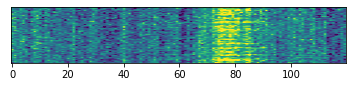

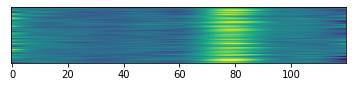

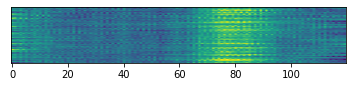

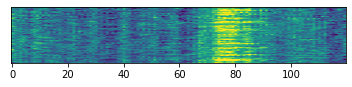

In [112]:
behave='flat'
fig,axs = plt.subplots()
axs.imshow(supervox_dict[behave]['signals'][50], vmax=0.01, vmin=-0.01)
axs.set_yticks([])
axs.set_aspect(0.01)
# fig,axs = plt.subplots(figsize=(50,100))
# axs.imshow(blur_data[50], vmax=0.01, vmin=-0.01)
# # axs.axvline((np.arange(0,120,20)), color='k')
# axs.set_yticks([])
# axs.set_aspect(0.01)
fig,axs = plt.subplots()
axs.imshow(lowpass_dict[behave][50], vmax=0.01, vmin=-0.01)
# axs.axvline((np.arange(0,120,20)), color='k')
axs.set_yticks([])
axs.set_aspect(0.01)
fig,axs = plt.subplots()
axs.imshow(comb_dict[behave][50], vmax=0.01, vmin=-0.01)
axs.set_yticks([])
axs.set_aspect(0.01)
fig,axs = plt.subplots()
axs.imshow(iir_comb_dict[behave][50], vmax=0.01, vmin=-0.01)
axs.set_yticks([])
axs.set_aspect(0.01)

In [26]:
np.shape(supervox_dict[behave]['signals'])

(91, 2000, 120)

In [52]:
data=supervox_dict[behave]['signals']
xx = np.mean(data[50,0:1000,:], axis=0)
print(np.shape(xx))
xx = xx/max(xx)
fs=50
f0 = 2 # Frequency to be removed from signal (Hz)
Q = 2.0  # Quality factor

b_notch,a_notch=iirnotch(f0, Q, fs)
b, a = butter(3, f0/(fs/2), btype='low', analog=False)
responses_notch = filtfilt(b_notch,a_notch, xx)
print(np.shape(responses_notch))

(120,)
(120,)


In [81]:
test=xx
mult=1
samp=2
for i in range(int(fs)):
    harm=samp*mult
    print(mult,harm)
    try:
        b_notch,a_notch=iirnotch(harm, Q, fs)
        responses_notch_temp = filtfilt(b_notch,a_notch, test)
        test=responses_notch_temp
        mult*=2
#         samp=harm
    except:
        break

1 2
2 4
4 8
8 16
16 32


In [82]:
freqs_p, psd_p = scipy.signal.periodogram(responses_notch, fs=fs)
freqs_p0, psd_p0 = scipy.signal.periodogram(xx, fs=fs)
freqs_p1, psd_p1 = scipy.signal.periodogram(test, fs=fs)

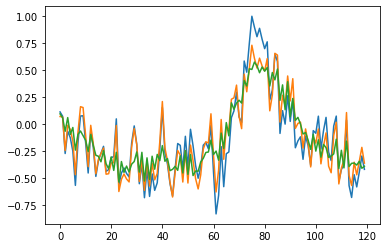

In [83]:
plt.plot(xx);
plt.plot(responses_notch);
plt.plot(test);

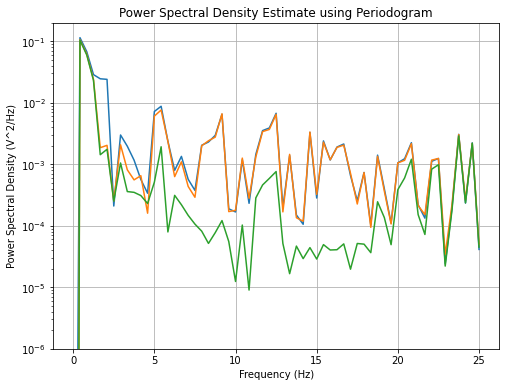

In [84]:
plt.figure(figsize=(8, 6))
plt.semilogy(freqs_p0, psd_p0)
plt.semilogy(freqs_p, psd_p)
plt.semilogy(freqs_p1, psd_p1)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (V^2/Hz)')
plt.title('Power Spectral Density Estimate using Periodogram')
plt.grid(True)
plt.ylim([1e-6, 0.2])
plt.show()

In [31]:
# random_dist=np.random.rand()

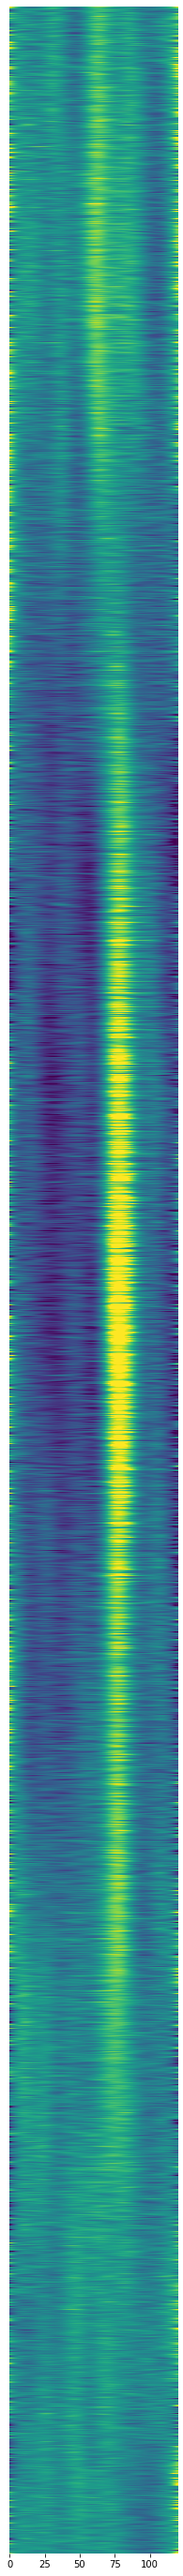

In [344]:
b='flat'
data=lowpass_dict[b]
num_areas=np.shape(data)[0]
fig = plt.figure(figsize=(10,50))
gs = fig.add_gridspec(nrows=num_areas, ncols=1, hspace=0)
axs = gs.subplots(sharex='col', sharey=False)
for i in range(num_areas):
    axs[i].imshow(data[i], vmax=0.005, vmin=-0.005)
    axs[i].set_yticks([])
#     axs[i].set_xticks([])
    axs[i].set_aspect(0.01)
#     axs[i].set_ylabel(f'z={i}', rotation=0, labelpad=20)
for ax in axs:
    ax.label_outer()
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.show()

In [28]:
# behave='total'
# x,y,t=np.shape(supervox_dict[behave]['signals'])
# plt.figure(figsize=(10,10))
# plt.plot(supervox_dict[behave]['signals'].reshape(x*y,t).T, color='gray', alpha=0.05);
# plt.plot(np.mean(supervox_dict[behave]['signals'].reshape(x*y,t), axis=-1).T, color='k', lw=3);
# plt.ylim(-0.05, 0.05);

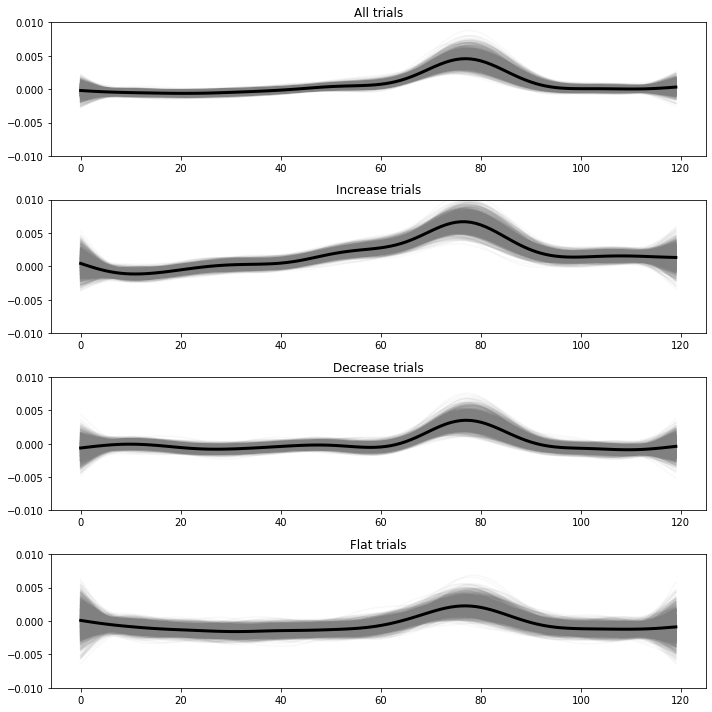

In [346]:
# plt.figure(figsize=(10,10))
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(10,10))
axs[0].plot(np.mean(lowpass_dict['total'], axis=0).T, color='gray', alpha=0.05);
axs[0].plot(np.mean(np.mean(lowpass_dict['total'], axis=0), axis=0).T, color='k', lw=3);
axs[0].set_title('All trials')
axs[0].set_ylim(-0.01, 0.01);
# axs[0].axvline(5.5,color='k', linestyle='--');
# axs[0].axvline(15.5,color='k', linestyle='--');
axs[1].plot(np.mean(lowpass_dict['inc'], axis=0).T, color='gray', alpha=0.05);
axs[1].plot(np.mean(np.mean(lowpass_dict['inc'], axis=0), axis=0).T, color='k', lw=3);
axs[1].set_title('Increase trials')
axs[1].set_ylim(-0.01, 0.01);
# axs[1].axvline(5.5,color='k', linestyle='--');
# axs[1].axvline(15.5,color='k', linestyle='--');
axs[2].plot(np.mean(lowpass_dict['dec'], axis=0).T, color='gray', alpha=0.05);
axs[2].plot(np.mean(np.mean(lowpass_dict['dec'], axis=0), axis=0).T, color='k', lw=3);
axs[2].set_title('Decrease trials')
axs[2].set_ylim(-0.01, 0.01);
# axs[2].axvline(5.5,color='k', linestyle='--');
# axs[2].axvline(15.5,color='k', linestyle='--');
axs[3].plot(np.mean(lowpass_dict['flat'], axis=0).T, color='gray', alpha=0.05);
# axs[3].scatter(np.arange(25).T,np.mean(supervox_dict['flat']['signals'], axis=0).T, color='gray', alpha=0.05)
axs[3].plot(np.mean(np.mean(lowpass_dict['flat'], axis=0), axis=0).T, color='k', lw=3);
axs[3].set_title('Flat trials')
axs[3].set_ylim(-0.01, 0.01);
# axs[3].axvline(5.5,color='k', linestyle='--');
# axs[3].axvline(15.5,color='k', linestyle='--');
# vals = list(range(0,24,1))
# axs[3].axvline(vals,color='k', alpha=0.3);
# plt.grid(which='both',alpha=0.3)
fig.tight_layout()
plt.show()

In [347]:
atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [349]:
# %%time
# # roi_num=np.full((dims_test[0], dims_test[1]), np.nan)
# # print(np.shape(roi_num))
# # roi_name=np.zeros((dims_test[0], dims_test[1]), dtype=str)
key_to_name={}
dims=np.shape(giant_cluster_labels)
giant_area_labels=np.zeros_like(giant_cluster_labels)
for area in explosion_rois:
    for key in explosion_rois[area]['rois']:
        area_name=explosion_rois[area]['rois'][key]
        if '_R' in area_name or '_L' in area_name:
            total_area_name=area_name.split('_')
            if len(total_area_name)==3:
                area_name=total_area_name[0]+'_'+total_area_name[1]
            else:
                area_name=total_area_name[0]
#         print(area_name)
        roi=key
        if key in key_to_name:
            key_to_name.append(area_name)
        else:
            key_to_name[roi]=area_name
        area_mask=np.asarray(roi_masks[roi])
        area_mask_flat=area_mask.reshape(dims[0], dims[1])
        giant_area_labels=np.where(area_mask_flat==False, giant_area_labels, roi)
#         print(np.shape(giant_area_labels))
#         print(np.count_nonzero(giant_area_labels))
#         print(f'ROI num: {np.count_nonzero(giant_area_labels==roi)}')

In [350]:
print(np.shape(giant_cluster_labels[50,:]))
print(np.nanmax(giant_area_labels[50,:]))
test=np.copy(giant_area_labels)

(45844,)
83


In [351]:
x,y,t = np.shape(supervox_dict[behave]['signals'])
cluster_rois = np.zeros((x,y))
# np.shape(cluster_rois)
for i in range(x):
    for j in range(y):
        idxs=np.where(giant_cluster_labels[i]==j)
#         print(f'Z {i} and cluster {j} have areas {np.unique(test[i][idxs])}')

In [352]:
# key_to_name

In [465]:
%%time
full_res={}
for behave in behaviors:
    print(behave)
    supervox_brain=gaussian_filter(lowpass_dict[behave], sigma=1.5)
    supervox_brain=np.moveaxis(supervox_brain,-1,-2)
#     print(np.shape(supervox_brain))
    full_res_brain=supervoxel_to_full_res(supervox_brain, giant_cluster_labels)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    print(np.shape(full_res_brain))
    full_res[behave]=np.asarray(full_res_brain)

total
(120, 314, 146, 91)
inc
(120, 314, 146, 91)
dec
(120, 314, 146, 91)
flat
(120, 314, 146, 91)
CPU times: user 54.6 s, sys: 6.82 s, total: 1min 1s
Wall time: 1min 1s


In [466]:
%%time

def moving_average_2d(arr, window_size=25):
    # Apply uniform filter to compute the moving average
    return uniform_filter(arr, size=window_size, mode='constant')

def sort_rows_by_max_index(arr):
    # Find the index of the maximum value in each row
    arr_avg=moving_average_2d(arr,window_size=5)
    max_indices = np.argmax(arr_avg, axis=1)
    
    # Get the sorted order of the rows based on the max indices
    sorted_order = np.argsort(max_indices)
    
    # Sort the rows of the array based on the sorted order
    sorted_arr = arr[sorted_order]
    return sorted_arr


total_vox_sorted={}
for behavior in full_res:
    STA=full_res[behavior]
    total_vox_sorted[behavior]={}
    for area in explosion_rois:
        for key in explosion_rois[area]['rois']:
            area_name=explosion_rois[area]['rois'][key]
            if '_R' in area_name or '_L' in area_name:
                total_area_name=area_name.split('_')
                if len(total_area_name)==3:
                    area_name=total_area_name[0]+'_'+total_area_name[1]
                else:
                    area_name=total_area_name[0]
            roi=key
            roi_mask=roi_masks[roi]
            masked_roi=[STA[i][roi_mask] for i in range(np.shape(STA)[0])]
            masked_roi=np.transpose(masked_roi)
    #         roi_sort=sort_rows_by_max_index(masked_roi)
            try:
                np.append(total_vox_sorted[behavior][area_name], masked_roi)
            except KeyError:
                total_vox_sorted[behavior][area_name]=masked_roi
for behavior in total_vox_sorted:
    for key in total_vox_sorted[behavior]:
        total_vox_sorted[behavior][key]=sort_rows_by_max_index(total_vox_sorted[behavior][key])

CPU times: user 43.6 s, sys: 2.52 s, total: 46.2 s
Wall time: 46.2 s


In [467]:
np.shape(total_vox_sorted[behavior]['FB'])

(12480, 120)

In [487]:
step_size=20
step_10=np.array([[0.00006,-0.00002],[60,160]])
step_100=np.array([[0.01,-0.003],[6,16]])
step_20=np.array([[0.007,-0.003],[30,80]])

In [488]:
def plot_heatmap_area(areas_dict, area, ax, step_size):
    if step_size==10:
        stuff=step_10
    elif step_size==20:
        stuff=step_20
    else:
        stuff=step_100
    ax.imshow(areas_dict[area], aspect='auto',vmax=stuff[0,0], vmin=stuff[0,1], cmap='plasma')
    ax.set_ylabel(area, rotation=0, labelpad=20)
    ax.axvline(x=stuff[1,0], ymin=0, ymax=1, ls='--', color='w', lw=2)
    ax.axvline(x=stuff[1,1], ymin=0, ymax=1, ls='--', color='w', lw=2)
    ax.set_yticks([])

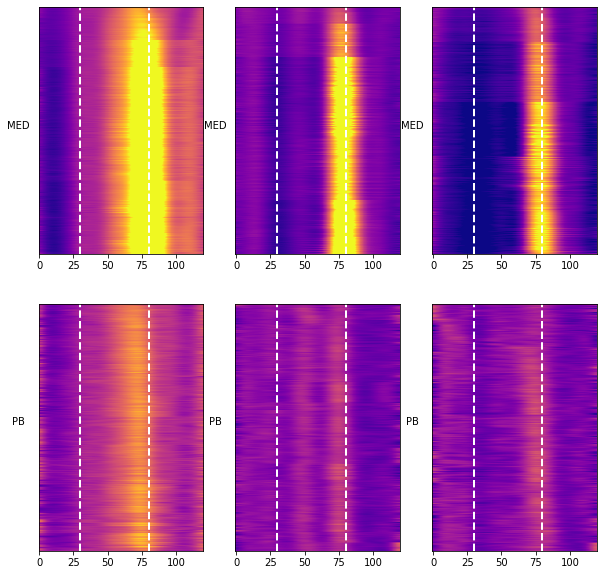

In [489]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10,10))
plot_heatmap_area(total_vox_sorted['inc'], 'MED', axs[0,0], step_size)
plot_heatmap_area(total_vox_sorted['dec'], 'MED', axs[0,1], step_size)
plot_heatmap_area(total_vox_sorted['flat'], 'MED', axs[0,2], step_size)
plot_heatmap_area(total_vox_sorted['inc'], 'PB', axs[1,0], step_size)
plot_heatmap_area(total_vox_sorted['dec'], 'PB', axs[1,1], step_size)
plot_heatmap_area(total_vox_sorted['flat'], 'PB', axs[1,2], step_size)

In [490]:
def plot_heatmap_allareas(areas_dict):
    num_areas=len(areas_dict)
    heights = [np.shape(areas_dict[key])[0] for key in areas_dict]
    heights = heights/np.min(heights)
    heights_final = [int(x) for x in heights]
    fig = plt.figure(figsize=(5,10))
    gs = fig.add_gridspec(nrows=num_areas, ncols=1, height_ratios=heights, hspace=0)
    axs = gs.subplots(sharex='col', sharey=False)
    for i,key in enumerate(areas_dict):
        plot_heatmap_area(areas_dict, key, axs[i],step_size)
    for ax in axs:
        ax.label_outer()
#         ax.spines['top'].set_visible(False)
#         ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
#         ax.set_yticks([])
        
    plt.show()

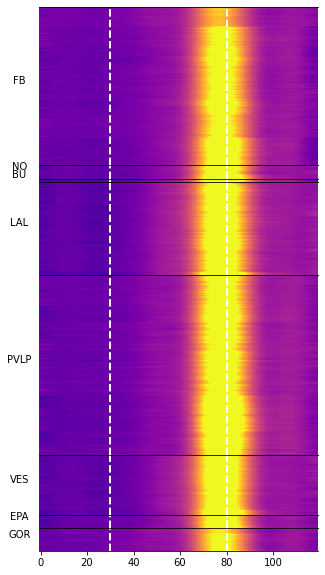

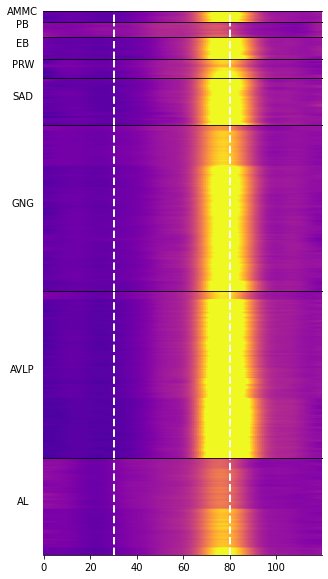

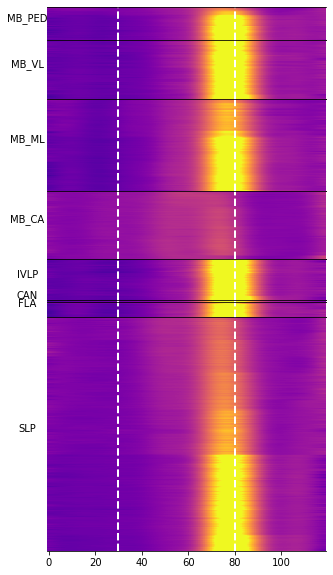

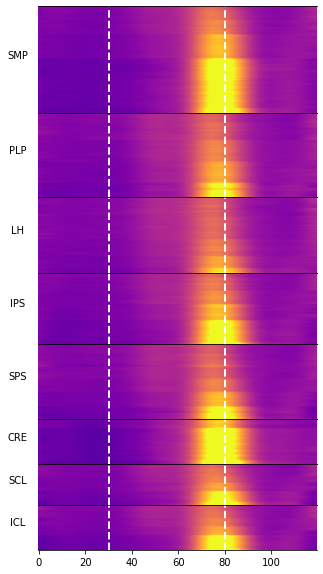

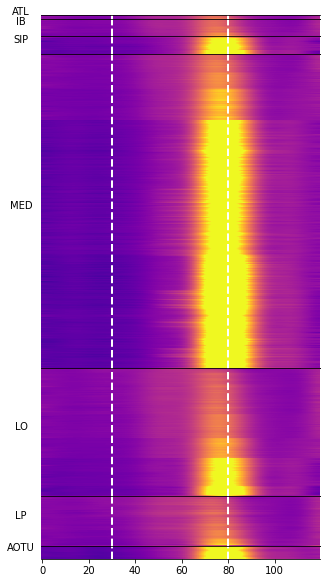

In [491]:
behavior='total'
areas = int((len(total_vox_sorted[behavior])+1)/5)
for i in range(0,len(total_vox_sorted[behavior]), areas):
    end = i + areas if i + areas < len(total_vox_sorted[behavior]) else len(total_vox_sorted[behavior])
    sliced_keys = list(total_vox_sorted[behavior].keys())[i:end]
    sliced_dict = {k: total_vox_sorted[behavior][k] for k in sliced_keys if k in total_vox_sorted[behavior]}
    plot_heatmap_allareas(sliced_dict)

In [68]:
%%time
for key in supervox_dict:
    signal_move=np.moveaxis(supervox_dict[key]['signals'], 1,-1)
#     print(np.shape(signal_move))
    reformed_brain = supervoxel_to_full_res(signal_move, giant_cluster_labels)
    final_brain = gaussian_filter1d(reformed_brain,sigma=1,axis=1,truncate=1)
    final_brain = np.moveaxis(final_brain, 0, -1)
    dims=np.shape(final_brain)
    print(dims)
    supervox_dict[key]['reformed']=final_brain

(24, 314, 146, 91)
(24, 314, 146, 91)
(24, 314, 146, 91)
(24, 314, 146, 91)
CPU times: user 50.1 s, sys: 1.6 s, total: 51.7 s
Wall time: 51.7 s


In [69]:
z=45
t=15

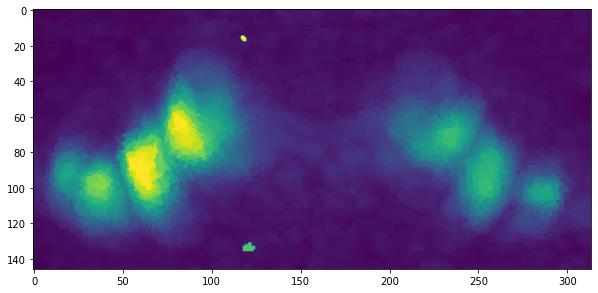

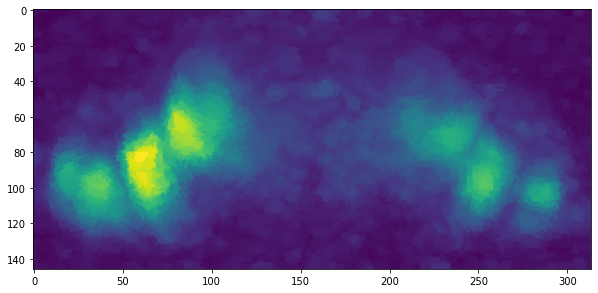

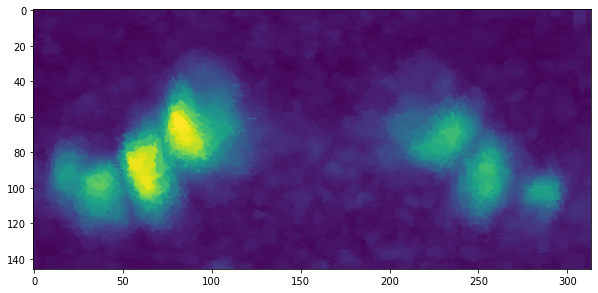

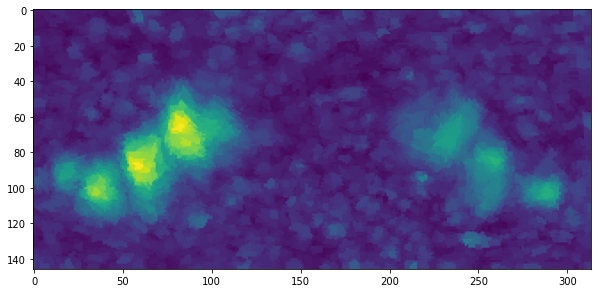

In [72]:
plt.figure(figsize=(10,10))
plt.imshow(np.max(supervox_dict['total']['reformed'][t], axis=-1).T, vmax=0.1)
plt.figure(figsize=(10,10))
plt.imshow(np.max(supervox_dict['inc']['reformed'][t], axis=-1).T)
plt.figure(figsize=(10,10))
plt.imshow(np.max(supervox_dict['dec']['reformed'][t], axis=-1).T)
plt.figure(figsize=(10,10))
plt.imshow(np.max(supervox_dict['flat']['reformed'][t], axis=-1).T)

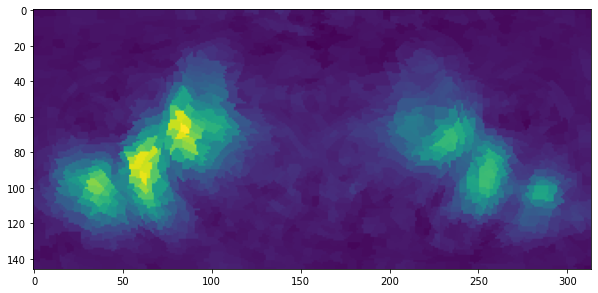

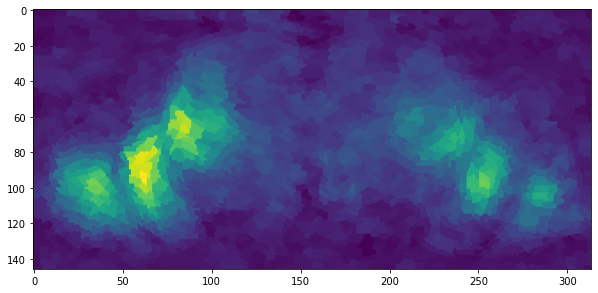

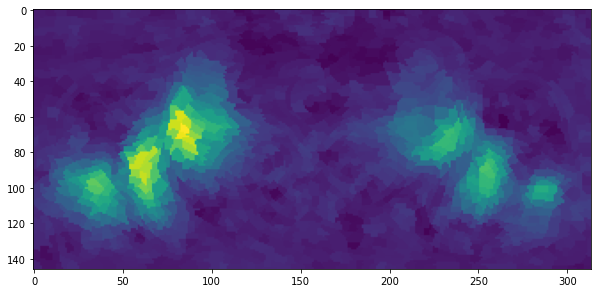

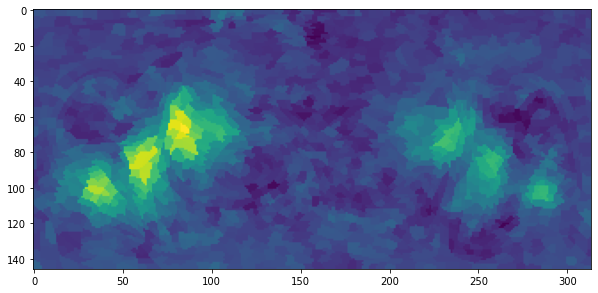

In [59]:
plt.figure(figsize=(10,10))
plt.imshow(supervox_dict['total']['reformed'][t][...,z].T)
plt.figure(figsize=(10,10))
plt.imshow(supervox_dict['inc']['reformed'][t][..., z].T)
plt.figure(figsize=(10,10))
plt.imshow(supervox_dict['dec']['reformed'][t][..., z].T)
plt.figure(figsize=(10,10))
plt.imshow(supervox_dict['flat']['reformed'][t][...,z].T)

In [35]:
atlas = brainsss.load_roi_atlas()

In [36]:
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [37]:
def extract_roi_signal_traces(roi_ids, roi_masks, warps, hemi, signal_type):
    t0 = time.time()
    roi_time_avgs = []
    for roi in roi_ids[hemi]:
        mask = roi_masks[roi]
        masked_data = warps[:,:,:,:]*mask[np.newaxis,:,:,:] #note z-flip
        if signal_type == 'max':
            roi_time_avg = np.max(masked_data,axis=(1,2,3))
        elif signal_type == 'mean':
            roi_time_avg = np.mean(masked_data,axis=(1,2,3))
        roi_time_avgs.append(roi_time_avg)
    print(time.time()-t0)
    return np.asarray(roi_time_avgs)

In [49]:
%%time
explosions = []
for tp in range(24):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    data_to_plot = supervox_dict['flat']['reformed'][tp][:,:,::-1]
    vmax = 0.1 #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap='seismic', diverging=True)#'hot')
    explosions.append(explosion_map)

CPU times: user 24 s, sys: 279 ms, total: 24.3 s
Wall time: 24.3 s


(-0.5, 499.5, 329.5, -0.5)

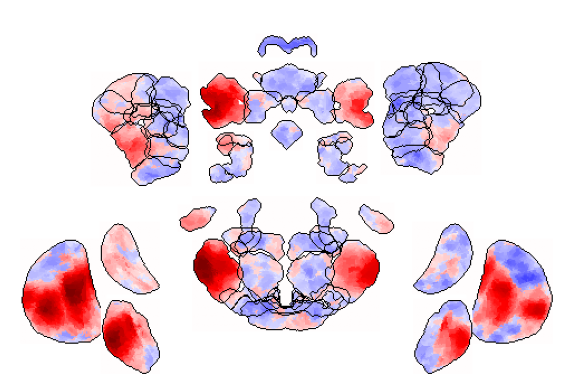

In [51]:
plt.figure(figsize=(10,10))
plt.imshow(explosions[15][170:,:]) #this was made with cmap=hot
plt.axis('off')

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/total/movies
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/inc/movies
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/dec/movies
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/flat/movies
CPU times: user 4min 40s, sys: 1min 34s, total: 6min 15s
Wall time: 6min 19s


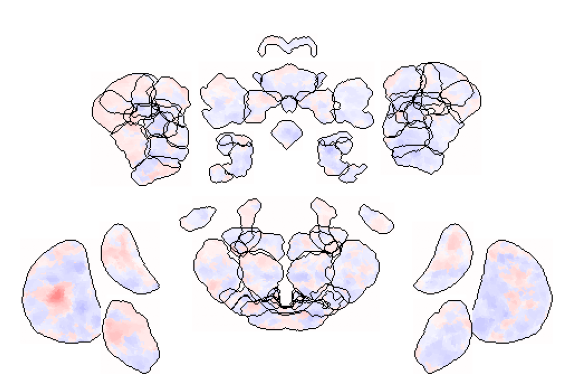

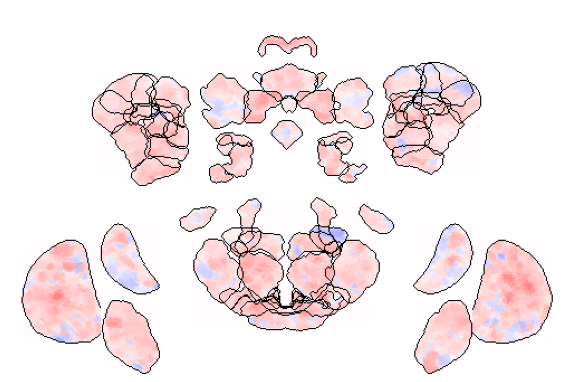

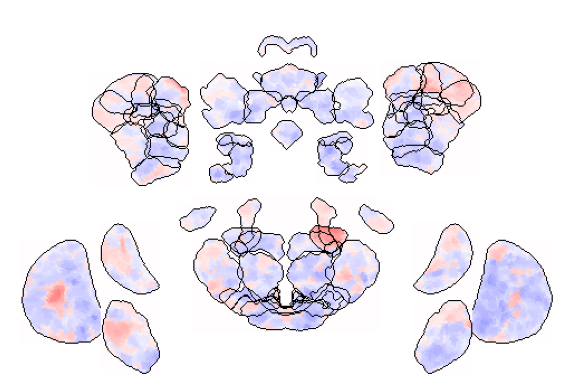

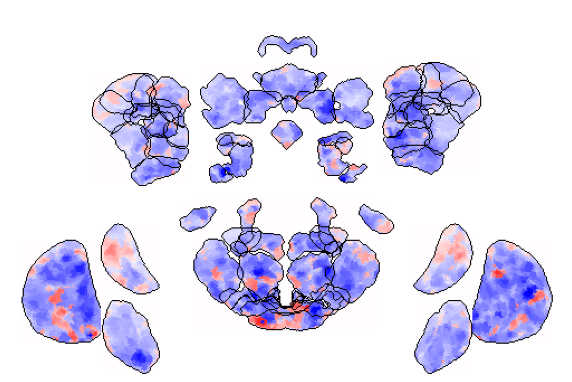

In [52]:
%%time
for behavior in behaviors:
    behave_dir = os.path.join(later_dir, behavior)
    movie_dir = os.path.join(behave_dir, 'movies')
    if os.path.exists(movie_dir)==False:
        os.mkdir(movie_dir)
    print(movie_dir)
    explosions = []
    for tp in range(24):
        input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
        data_to_plot = supervox_dict[behavior]['reformed'][tp][:,:,::-1]
        vmax = 0.1 #this was 0.5 for STA <------------
        explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                            roi_masks,
                                                            roi_contours,
                                                            data_to_plot,
                                                            input_canvas,
                                                            vmax=vmax,
                                                            cmap='seismic', diverging=True)#'hot')
        explosions.append(explosion_map)
    plt.figure(figsize=(10,10))
    for i in range(24):
#         print(i)
        plt.imshow(explosions[i][170:,:]) #this was made with cmap=hot
        plt.axis('off')
        fname = os.path.join(movie_dir, '{0:05d}.png'.format(i))
        plt.savefig(fname,dpi=300,bbox_inches='tight')